In [2]:
import numpy as np
from hydrax.utils.files import get_root_path

# Load the .npy file
seed = 36
current_dir = get_root_path() #/ "experiments/bugtrap_escape"
# data = np.load("./../data/error_log_pushT/error_log.npy")
cem_data = np.load(current_dir / "data/error_log_pushT/cem_{seed}.npy".format(seed=seed))
mppi_data = np.load(current_dir / "data/error_log_pushT/mppi_{seed}.npy".format(seed=seed))
anmtp_data = np.load(current_dir / "data/error_log_pushT/anmtp_{seed}.npy".format(seed=seed))
print("CEM data shape:", cem_data.shape)
print("MPPI data shape:", mppi_data.shape)
print("ANMTP data shape:", anmtp_data.shape)

# bring to same length by repeating last value
max_length = max(cem_data.shape[0], mppi_data.shape[0], anmtp_data.shape[0])
cem_data = np.pad(cem_data, ((0, max_length - cem_data.shape[0])), mode='edge')
mppi_data = np.pad(mppi_data, ((0, max_length - mppi_data.shape[0])), mode='edge')
anmtp_data = np.pad(anmtp_data, ((0, max_length - anmtp_data.shape[0])), mode='edge')

CEM data shape: (4008,)
MPPI data shape: (4008,)
ANMTP data shape: (2376,)


Data shape: (3, 4008)


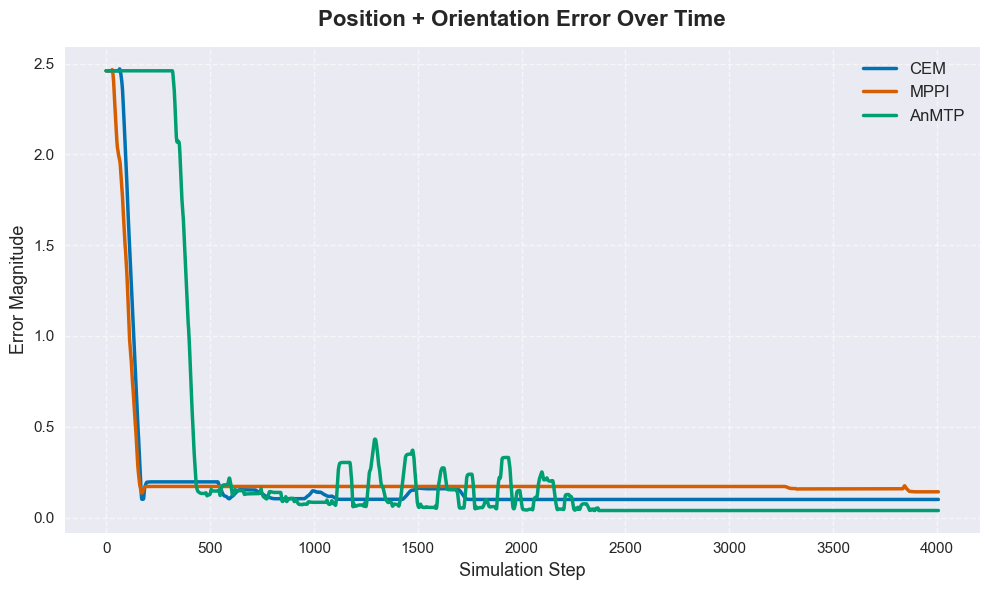

In [3]:
from matplotlib import colors
import matplotlib.pyplot as plt

data = np.concatenate([cem_data[None, :], mppi_data[None, :], anmtp_data[None, :]], axis=0)
# data = np.linalg.norm(data, axis=2)  # compute error magnitude
print("Data shape:", data.shape)

# If `data` is (num_runs, num_steps), compute stats across runs:
if data.ndim == 2:
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
else:
    mean = data
    std = np.zeros_like(data)

# --- Plot Style ---
plt.style.use("seaborn-v0_8")
# plt.style.use("ggplot")       # clean and light
# plt.style.use("bmh")          # soft grid
# plt.style.use("dark_background")  # sleek dark mode

fig, ax = plt.subplots(figsize=(10, 6))

steps = np.arange(len(mean))
colors = ["#0072B2", "#D55E00", "#009E73"]
name = ["CEM", "MPPI", "AnMTP"]

# --- Plot mean with standard deviation band ---
for i in range(data.shape[0]):
    # ax.plot(steps, data[i], color="#999999", alpha=0.3, linewidth=1)    
    ax.plot(steps, data[i], color=colors[i], linewidth=2.5, label=name[i])
    # ax.fill_between(steps, mean - std, mean + std, color="#0072B2", alpha=0.2, label="±1 Std. Dev.")

# --- Styling ---
ax.set_title("Position + Orientation Error Over Time", fontsize=16, weight="bold", pad=15)
ax.set_xlabel("Simulation Step", fontsize=13)
ax.set_ylabel("Error Magnitude", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(fontsize=12)
ax.tick_params(axis="both", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()